# Plotting Code for EXP3: Oracle controller

In [223]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle as pkl
import os
from knapsack_solver import KnapsackSolver
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, BootstrapMethod
os.chdir(r"""C:\Users\thgla\Documents\GitHub\ADALaS""")

In [53]:
FILENAMES = {
        1: r"data\test_results\alpaca\ULS_4L-1.3b_alpaca_28-08_04-01-03",
        2: r"data\test_results\alpaca\ULS_8L-1.3b_alpaca_28-08_02-48-04",
        3: r"data\test_results\alpaca\ULS_12L_run2-1.3b_alpaca_31-08_19-40-56",
        6: r"data\test_results\alpaca\full_prop-1.3b_alpaca_27-08_18-16-38"      
}

shards = 5
data_dict = {}
for k in FILENAMES:
    data_dict[k] = [pkl.load(open(FILENAMES[k] + f"\shard_{i}.pkl", "rb")) for i in range(shards)]

df_dict = {
    1: pd.DataFrame(columns=["rouge_L_ind", "label_length"]),
    2: pd.DataFrame(columns=["rouge_L_ind", "label_length"]),
    3: pd.DataFrame(columns=["rouge_L_ind", "label_length"]),
    6: pd.DataFrame(columns=["rouge_L_ind", "label_length"])
}

for k in data_dict:
    for i in range(shards):
        df_dict[k] = pd.concat([df_dict[k], pd.DataFrame.from_dict({"rouge_L_ind":data_dict[k][i]["rouge_L_ind"], "label_length":data_dict[3][i]["label_length"]})])  

C:\Users\thgla\AppData\Local\Temp\ipykernel_51912\2725941958.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dict[k] = pd.concat([df_dict[k], pd.DataFrame.from_dict({"rouge_L_ind":data_dict[k][i]["rouge_L_ind"], "label_length":data_dict[3][i]["label_length"]})])


In [50]:
print(df_dict[3].describe())

       rouge_L_ind
count  7801.000000
mean      0.320823
std       0.237677
min       0.000000
25%       0.176991
50%       0.266667
75%       0.396825
max       1.000000


In [54]:
values = np.vstack([df['rouge_L_ind'].values for df in df_dict.values()]).T
indices = np.vstack([[k]*len(df) for k, df in df_dict.items()]).T
#weights = np.vstack([[k*int(df['label_length'][i]) for i in range(len(df))]  for k, df in df_dict.items()]).T
weights = np.copy(indices)

#convert weights to integers
weights = weights.astype(int)
print(values[:5])
print(weights[:5])
print(indices[:5])
print(values.shape)
print(weights.shape)


[[0.24615385 0.265625   0.23333333 0.25938567]
 [0.13571429 0.37931034 0.37113402 0.37795276]
 [0.8        0.8        0.66666667 0.8       ]
 [0.18811881 0.23391813 0.07407407 0.21656051]
 [0.2        0.75       0.85714286 0.75      ]]
[[1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]]
[[1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]]
(7801, 4)
(7801, 4)


In [55]:
print(np.sum(weights, axis=0))
# print(np.mean(df_dict[2]['label_length'].values))

[ 7801 15602 23403 46806]


In [56]:
#sort each row by value, and apply the same permutation to weights
sort_perm = np.argsort(-values, axis=1)
values_sorted = np.take_along_axis(values, sort_perm, axis=1)
weights_sorted = np.take_along_axis(weights, sort_perm, axis=1)
indices_sorted = np.take_along_axis(indices, sort_perm, axis=1)

In [57]:
print(values_sorted[:5])
print(weights_sorted[:5])
print(indices_sorted[:5])

[[0.265625   0.25938567 0.24615385 0.23333333]
 [0.37931034 0.37795276 0.37113402 0.13571429]
 [0.8        0.8        0.8        0.66666667]
 [0.23391813 0.21656051 0.18811881 0.07407407]
 [0.85714286 0.75       0.75       0.2       ]]
[[2 6 1 3]
 [2 6 3 1]
 [1 2 6 3]
 [2 6 1 3]
 [3 2 6 1]]
[[2 6 1 3]
 [2 6 3 1]
 [1 2 6 3]
 [2 6 1 3]
 [3 2 6 1]]


In [58]:
max_capacity = sum(max(w) for w in weights_sorted)
print(max_capacity)

46806


In [59]:
kp_solver = KnapsackSolver(values_sorted, weights_sorted, indices_sorted, shard_number=10, max_layer=6)

kp_solver.solve()

In [60]:
betas = [x/100.0 for x in range(100, 600)]
optimal_rouges = np.array([kp_solver.get_optimal_value(beta) for beta in betas])

In [61]:
ULS_constant_rouges = [df['rouge_L_ind'].mean() for df in df_dict.values()]
ULS_layer_use = [k*4 for k in df_dict.keys()]

optimal_rouge_layer_use = [b*4 for b in betas]

In [62]:
print(ULS_constant_rouges)

[0.2492802059622771, 0.3085482705226395, 0.3208230317779097, 0.341822462065475]


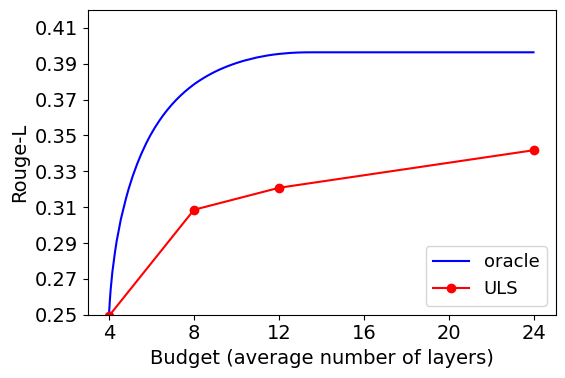

In [63]:
plt.figure(figsize=(6,4))
#font size
plt.rc('font', size=14)
plt.plot(optimal_rouge_layer_use, optimal_rouges, label='oracle', color='blue')
#scatter with line connecting points
plt.plot(ULS_layer_use, ULS_constant_rouges, label='ULS', color='red', marker='o')
#compare AUC
#plt.fill_between(ULS_layer_use, ULS_constant_rouges, alpha=0.2, color='red')
#plt.fill_between(optimal_rouge_layer_use, optimal_rouges, alpha=0.2, color='blue')
plt.xlabel('Budget (average number of layers)')
plt.ylabel('Rouge-L')
#change y range
plt.ylim(0.25, 0.42)
plt.legend(loc='lower right', fontsize=13)
#plt.xticks(np.arange(8, 25, 1))
plt.xticks(np.arange(1*4, 6*4 + 0.001, 1*4))
plt.tight_layout()
plt.yticks(np.arange(0.25, 0.42, 0.02))
#save pdf
#plt.savefig(r"data\rouge_scores_ULS\Alpaca\oracle.pdf", bbox_inches='tight')
plt.show()
#why is savefig showing a blank image?
#A: 



In [64]:
indices_lookup = [1,2,3,6]

average_layers = [1, 1.25,1.5,1.75,2,2.25,2.5,2.75,3,3.25,3.5,3.75,4,4.25,4.5,4.75,5,5.25,5.5,5.75,6]
choices_for_layer = [kp_solver.reconstruct_chosen_items(layer) for layer in average_layers]
occurences_model = [[0,0,0,0] for _ in range(len(choices_for_layer))]
#label_lengths_for_model = [[0,0,0,0] for _ in range(len(choices_for_layer))]
layer_choices = [[] for _ in range(len(choices_for_layer))]
for i in range(len(choices_for_layer)):
    occurences_model[i][0] += choices_for_layer[i].count(1) / values.shape[0]
    occurences_model[i][1] += choices_for_layer[i].count(2) / values.shape[0]
    occurences_model[i][2] += choices_for_layer[i].count(3) / values.shape[0]
    occurences_model[i][3] += choices_for_layer[i].count(6) / values.shape[0]
    for k in range(len(choices_for_layer[i])):
        layer_choice = choices_for_layer[i][k]
        layer_choices[i].append(layer_choice)
        idx = indices_lookup.index(layer_choice)
    #     label_lengths_for_model[i][idx] += df_dict[layer_choice]['prediction_length'][k]
    # # divide by number of items
    # label_lengths_for_model[i][0] /= choices_for_layer[i].count(1) if choices_for_layer[i].count(1) != 0 else 1
    # label_lengths_for_model[i][1] /= choices_for_layer[i].count(2) if choices_for_layer[i].count(2) != 0 else 1
    # label_lengths_for_model[i][2] /= choices_for_layer[i].count(3) if choices_for_layer[i].count(3) != 0 else 1
    # label_lengths_for_model[i][3] /= choices_for_layer[i].count(6) if choices_for_layer[i].count(6) != 0 else 1
    # label_lengths_for_model[i][0] /= np.mean(df_dict[1]['prediction_length'].values)
    # label_lengths_for_model[i][1] /= np.mean(df_dict[2]['prediction_length'].values)
    # label_lengths_for_model[i][2] /= np.mean(df_dict[3]['prediction_length'].values)
    # label_lengths_for_model[i][3] /= np.mean(df_dict[6]['prediction_length'].values)
    

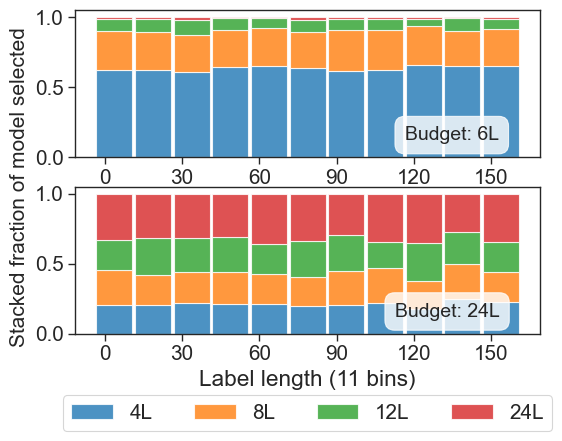

In [143]:
label_lengths = df_dict[1]['label_length'].values
avg_layer = np.array([6,24])
bs = avg_layer - 4
layer_choices_for_bs = [layer_choices[b] for b in bs]

layer_use_1 = [None,None]
layer_use_2 = [None,None]
layer_use_3 = [None,None]
layer_use_6 = [None,None]

for k, layer_choices_for_b in enumerate(layer_choices_for_bs):
    #group the layer choices into bins, determined bt the label lengths
    layer_choices_for_b = np.array(layer_choices_for_b)
    label_lengths = np.array(label_lengths)

    bins = np.linspace(0, 150, 11)
    digitized = np.digitize(label_lengths, bins)
    binned_layer_choices = [[0,0,0,0] for _ in range(len(bins))]
    for i in range(len(label_lengths)):
        bin_idx = digitized[i]
        layer_choice = layer_choices_for_b[i]
        layer_choice_idx = indices_lookup.index(layer_choice)
        binned_layer_choices[bin_idx-1][layer_choice_idx] += 1

    #normalize by the number of items in each bin
    for i in range(len(binned_layer_choices)):
        total_items = sum(binned_layer_choices[i])
        binned_layer_choices[i] = [x/total_items for x in binned_layer_choices[i]] if total_items != 0 else [0,0,0,0]

    layer_use_1[k] = [binned_layer_choice[0] for binned_layer_choice in binned_layer_choices]
    layer_use_2[k] = [binned_layer_choice[1] for binned_layer_choice in binned_layer_choices]
    layer_use_3[k] = [binned_layer_choice[2] for binned_layer_choice in binned_layer_choices]
    layer_use_6[k] = [binned_layer_choice[3] for binned_layer_choice in binned_layer_choices]

sns.set_theme(context="paper", style="ticks",font_scale=1.7,palette="tab10")
#plot 2 stacked figures
plt.figure(figsize=(6,4.2))
plt.rc('font', size=14)
#top plot
plt.subplot(2,1,1)
plt.bar(bins+3.75, layer_use_1[0], width=14, alpha=0.8, label='4L')
plt.bar(bins+3.75, layer_use_2[0], width=14, alpha=0.8, label='8L', bottom=layer_use_1[0])
plt.bar(bins+3.75, layer_use_3[0], width=14, alpha=0.8, label='12L', bottom=np.array(layer_use_1[0]) + np.array(layer_use_2[0]))
plt.bar(bins+3.75, layer_use_6[0], width=14, alpha=0.8, label='24L', bottom=np.array(layer_use_1[0]) + np.array(layer_use_2[0]) + np.array(layer_use_3[0]))
plt.xticks(np.arange(0, 165, 30))

#second plot
plt.subplot(2,1,2)
plt.bar(bins+3.75, layer_use_1[1], width=14, alpha=0.8, label='4L')
plt.bar(bins+3.75, layer_use_2[1], width=14, alpha=0.8, label='8L', bottom=layer_use_1[1])
plt.bar(bins+3.75, layer_use_3[1], width=14, alpha=0.8, label='12L', bottom=np.array(layer_use_1[1]) + np.array(layer_use_2[1]))
plt.bar(bins+3.75, layer_use_6[1], width=14, alpha=0.8, label='24L', bottom=np.array(layer_use_1[1]) + np.array(layer_use_2[1]) + np.array(layer_use_3[1]))
#single legend along bottom, horizontal
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=4)
plt.xlabel('Label length (11 bins)')
# single y label 
plt.text(-0.14, 1, 'Stacked fraction of model selected', va='center', rotation='vertical', transform=plt.gca().transAxes, fontsize=15)
plt.xticks(np.arange(0, 165, 30))

#write budget for each plot, with a filled box
plt.text(0.81, 1.35, 'Budget: 6L', va='center', ha='center', transform=plt.gca().transAxes, bbox=dict(facecolor='white', boxstyle='round,pad=0.5', alpha=0.8))
plt.text(0.8, 0.15, 'Budget: 24L', va='center', ha='center', transform=plt.gca().transAxes, bbox=dict(facecolor='white', boxstyle='round,pad=0.5', alpha=0.8))
plt.savefig(r"data\rouge_scores_ULS\Alpaca\sequence_bins.pdf", bbox_inches='tight')
plt.show()







In [227]:
corr_budget = 12
layer_choices_for_corr = np.array(layer_choices[corr_budget-4])
label_lengths = np.array(df_dict[1]['label_length'].values)
#comparison matrix
corr_matrix = np.zeros((4,4))
corr_matrix_p = np.zeros((4,4))
confidenc_interval_high = np.zeros((4,4))
confidenc_interval_low = np.zeros((4,4))
for i in range(4):
    for j in range(4):
        if i == j:
            corr_matrix[i,j] = np.nan
            corr_matrix_p[i,j] = np.nan
            continue
        preference_i = np.where(layer_choices_for_corr == indices_lookup[i], 1, 0)
        preference_j = np.where(layer_choices_for_corr == indices_lookup[j], -1, 0)
        combined_preference = preference_i + preference_j
        mask = combined_preference != 0
        combined_preference = combined_preference[mask]
        label_lengths_masked = label_lengths[mask]
        res = pearsonr(combined_preference, label_lengths_masked)
        confidenc_interval = res.confidence_interval(confidence_level=0.95, method=BootstrapMethod(n_resamples=1000))
        corr_matrix[i,j] = res[0]
        corr_matrix_p[i,j] = res[1]
        confidenc_interval_high[i,j] = confidenc_interval[1]
        confidenc_interval_low[i,j] = confidenc_interval[0]
        print(i)

res = pearsonr(layer_choices_for_corr, label_lengths)
confidence_interval = res.confidence_interval()
print(confidence_interval)



0
0
0
1
1
1
2
2
2
3
3
3
ConfidenceInterval(low=-0.015002806334575907, high=0.029377747551038825)


In [229]:
#save label lengths
np.save(r"data\rouge_scores_ULS\Alpaca\label_lengths.npy", label_lengths)
#save layer choice B = 6
np.save(r"data\rouge_scores_ULS\Alpaca\layer_choices_B6.npy", layer_choices[6-4])
#save layer choice B = 24\
np.save(r"data\rouge_scores_ULS\Alpaca\layer_choices_B24.npy", layer_choices[24-4])


([<matplotlib.axis.YTick at 0x16c1d495d30>,
 [Text(0, 0.5, '4L'),
  Text(0, 1.5, '8L'),
  Text(0, 2.5, '12L'),
  Text(0, 3.5, '24L')])

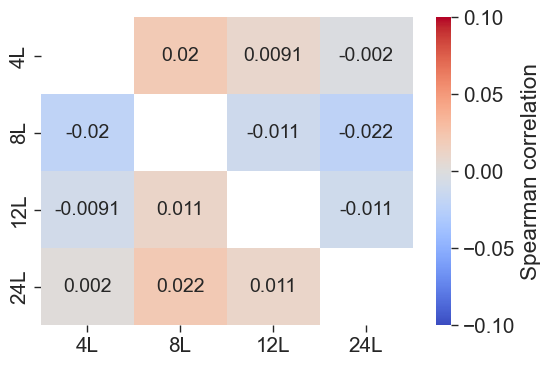

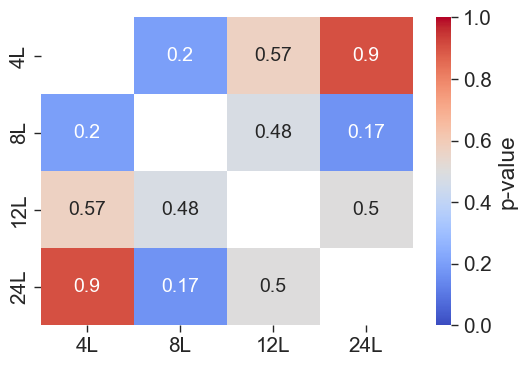

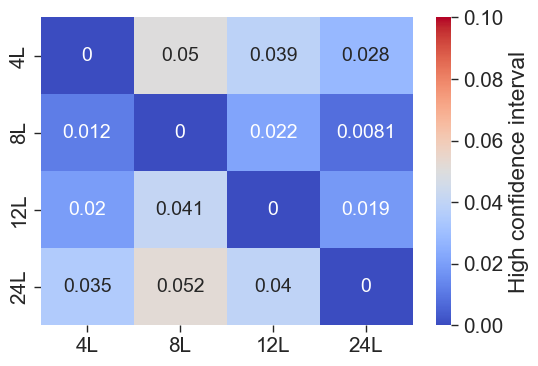

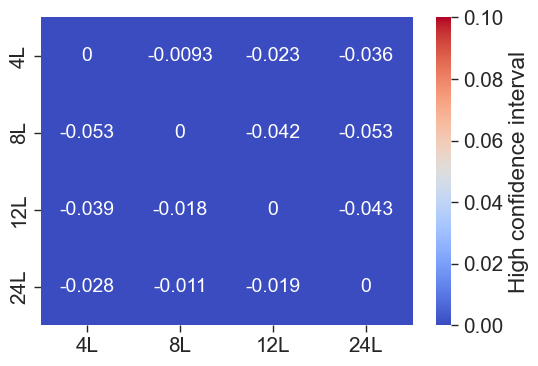

In [228]:
plt.figure(figsize=(6,4))
plt.rc('font', size=14)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', cbar_kws={'label': 'Spearman correlation'}, vmin=-0.1, vmax=0.1)
plt.xticks(np.arange(4) + 0.5, ['4L', '8L', '12L', '24L'])
plt.yticks(np.arange(4) + 0.5, ['4L', '8L', '12L', '24L'])

plt.figure(figsize=(6,4))
plt.rc('font', size=14)
sns.heatmap(corr_matrix_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'}, vmin=0, vmax=1.0)
plt.xticks(np.arange(4) + 0.5, ['4L', '8L', '12L', '24L'])
plt.yticks(np.arange(4) + 0.5, ['4L', '8L', '12L', '24L'])


plt.figure(figsize=(6,4))
plt.rc('font', size=14)
sns.heatmap(confidenc_interval_high, annot=True, cmap='coolwarm', cbar_kws={'label': 'High confidence interval'}, vmin=0, vmax=0.1)
plt.xticks(np.arange(4) + 0.5, ['4L', '8L', '12L', '24L'])
plt.yticks(np.arange(4) + 0.5, ['4L', '8L', '12L', '24L'])

plt.figure(figsize=(6,4))
plt.rc('font', size=14)
sns.heatmap(confidenc_interval_low, annot=True, cmap='coolwarm', cbar_kws={'label': 'High confidence interval'}, vmin=0, vmax=0.1)
plt.xticks(np.arange(4) + 0.5, ['4L', '8L', '12L', '24L'])
plt.yticks(np.arange(4) + 0.5, ['4L', '8L', '12L', '24L'])

In [144]:
occurences_model_np = np.array(occurences_model)


5.60304735477572


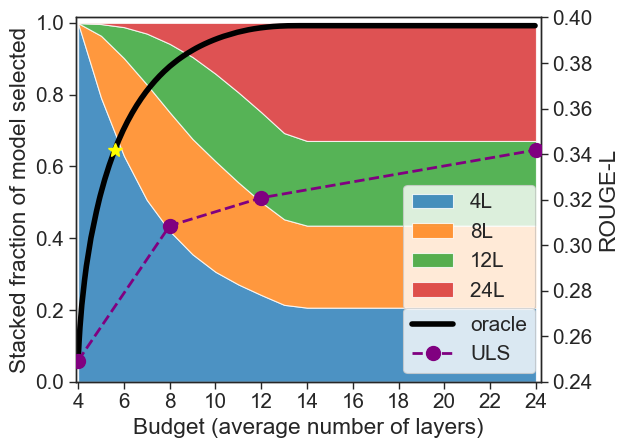

In [166]:
sns.set_theme(context="paper", style="ticks",font_scale=1.7,palette="tab10")
plt.figure(figsize=(6.5,4.7))
#font size
plt.rc('font', size=14)
# plot as stacked line chart,
plt.stackplot([a*4 for a in average_layers], occurences_model_np.T, labels=['4L', '8L', '12L', '24L    '],alpha=0.8)
#plt.plot(np.arange(8,25,1), budget_used, color='purple', linewidth=2)
plt.legend(loc=(0.705,0.200))
plt.xlabel('Budget (average number of layers)')
plt.ylabel('Stacked fraction of model selected')

#add vertical dashed line at 15
# plt.axvline(x=14, color='black', linestyle='--',ymax=0.96)
# #add text of values of occurences_model at 12
# for i, txt in enumerate(occurences_model_np[10]):
#     plt.text(14 +0.1, sum(occurences_model_np[10,:i]) + 0.48*occurences_model_np[10,i], str(round(txt,2)), color='black')

# for i, txt in enumerate(occurences_model_np[4]):
#     plt.text(11.1, sum(occurences_model_np[4,:i]) + 0.38*occurences_model_np[4,i], str(round(txt,2)), color='black')
plt.grid(False)
plt.ylim(0,1.015)
#add rouge socre on secondary y axis
plt.twinx()
plt.ylabel('ROUGE-L')
plt.plot(optimal_rouge_layer_use, optimal_rouges, label='oracle', color='black', linewidth=4)

plt.plot(ULS_layer_use, ULS_constant_rouges, label='ULS', color='purple', marker='o', linestyle='--', linewidth=2, markersize=10, zorder=10)

#add horizontal dashed line at full model
#plt.axhline(y=ULS_constant_rouges[-1], color='black', linestyle='--',xmin=0.08, linewidth=1)

#intesecting point of max uls and oracle
intersect = np.interp(ULS_constant_rouges[-1], optimal_rouges, optimal_rouge_layer_use)
print(intersect)
#plt.axvline(x=intersect, color='black', linestyle='--',ymax=0.63)
plt.plot(intersect, ULS_constant_rouges[-1], marker='*', color='yellow', markersize=10)

#plt.ylim(0.277, 0.360)
plt.ylim(0.24, 0.40)
plt.yticks(np.arange(0.24, 0.41, 0.02))

plt.legend(loc=(0.705,0.025))
#hide grid 
plt.grid(False)
plt.xlim(3.9,24.2)
plt.xticks(np.arange(4,25,2))
plt.tight_layout()
plt.savefig(r"data\rouge_scores_ULS\Alpaca\oracle_stacked.pdf", bbox_inches='tight')
plt.show()

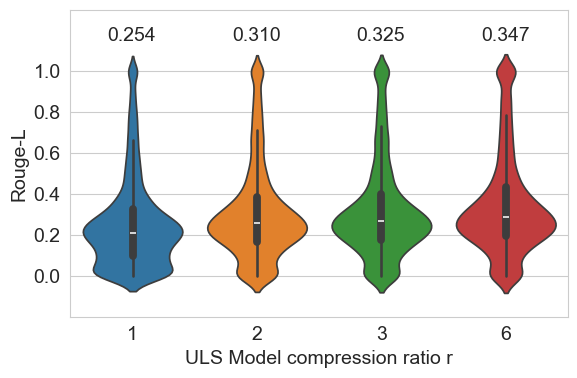

In [16]:
sns.set_style('whitegrid')
#violin plots of rouge scores, colorful
plt.figure(figsize=(6,4))
violin_data = {
    '1': df_dict[1]['rougeL'],
    '2': df_dict[2]['rougeL'],
    '3': df_dict[3]['rougeL'],
    '6': df_dict[6]['rougeL'],
}
sns.violinplot(data=violin_data)
#show average rouge scores
for i, (k, v) in enumerate(violin_data.items()):
    plt.text(i, v.mean(), f'{v.mean():.3f}', position=(i-0.2,1.15))
plt.xticks(np.arange(4), ['1', '2', '3', '6'])
plt.ylim(-0.2, 1.3)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylabel('Rouge-L')
plt.xlabel('ULS Model compression ratio r')
plt.tight_layout()